In [32]:
# ── CELDA 1: Importaciones y Configuración ────────────────────────────────────
import sys
import os

# 🔥 Configuración de rutas: Agregamos el directorio raíz para encontrar 'scripts'
directorio_raiz = os.path.abspath('..')
if directorio_raiz not in sys.path:
    sys.path.insert(0, directorio_raiz)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos: Árboles para Regresión (PIB) y Clasificación (Ingresos)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split

# Métricas para ambos mundos (¡Corregido: Incluye roc_curve y roc_auc_score!)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, # Clasificación
    r2_score, mean_absolute_error, mean_squared_error,                                 # Regresión
    confusion_matrix, ConfusionMatrixDisplay
)

# Conexión a base de datos
from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente para gráficas económicas
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120, 
    'font.size': 11,
    'figure.figsize': (10, 6)
})

print("✅ Entorno económico configurado correctamente")
print(f"📦 Pandas: {pd.__version__} | Numpy: {np.__version__}")
print("📊 Modelos y métricas listos (incluyendo ROC AUC)")
print("\n⚠️ Nota: Los árboles (CART) son robustos a la escala; usaremos los datos sin normalizar.")

✅ Entorno económico configurado correctamente
📦 Pandas: 2.2.2 | Numpy: 1.26.4
📊 Modelos y métricas listos (incluyendo ROC AUC)

⚠️ Nota: Los árboles (CART) son robustos a la escala; usaremos los datos sin normalizar.


In [33]:
# ── CELDA 2: Extracción SQL y Transformación ──────────────────────────────────
# Extraemos los datos crudos del Banco Mundial
SQL_QUERY = "SELECT pais, anio, indicador, valor FROM worldbank_registros ORDER BY pais, anio;"

with engine.connect() as conn:
    df_raw = pd.read_sql(text(SQL_QUERY), conn)

# 1. Pivotar: Convertimos filas de indicadores en columnas (PIB, Población, Inflación)
df_economico = df_raw.pivot_table(index=["pais", "anio"], columns="indicador", values="valor").reset_index()

# 2. Renombrar columnas para facilitar el manejo
rename_map = {}
for col in df_economico.columns:
    c_lower = str(col).lower()
    if "gdp" in c_lower or "pib" in c_lower: rename_map[col] = 'pib'
    elif "population" in c_lower or "poblacion" in c_lower: rename_map[col] = 'poblacion'
    elif "inflation" in c_lower or "inflacion" in c_lower: rename_map[col] = 'inflacion'

df_economico = df_economico.rename(columns=rename_map).copy()

# 3. Reemplazo de NaNs: Imputación por tendencia del país (Sin eliminar registros)
for col in ['pib', 'poblacion', 'inflacion']:
    if col in df_economico.columns:
        df_economico[col] = df_economico.groupby('pais')[col].transform(
            lambda x: x.interpolate(method='linear').ffill().bfill()
        )
        df_economico[col] = df_economico[col].clip(lower=0.01)

# 4. Creación de la Variable Objetivo para CLASIFICACIÓN
# Clasificamos: 1 si el PIB es mayor a la mediana (Ingreso Alto), 0 si es menor (Ingreso Bajo)
mediana_pib = df_economico['pib'].median()
df_economico['es_ingreso_alto'] = (df_economico['pib'] > mediana_pib).astype(int)

print(f"✅ Datos cargados y procesados: {df_economico.shape[0]:,} filas × {df_economico.shape[1]} columnas")
print(f"\nIndicadores procesados: {list(rename_map.values())}")

print(f"\nBalance de Clasificación (Ingreso Alto):")
bal = df_economico['es_ingreso_alto'].value_counts()
pct = df_economico['es_ingreso_alto'].value_counts(normalize=True) * 100
print(f"   Ingreso Alto (1): {bal[1]:,}  ({pct[1]:.1f}%)")
print(f"   Ingreso Bajo (0): {bal[0]:,}  ({pct[0]:.1f}%)")

df_economico.head()

✅ Datos cargados y procesados: 650 filas × 6 columnas

Indicadores procesados: ['pib', 'inflacion', 'poblacion']

Balance de Clasificación (Ingreso Alto):
   Ingreso Alto (1): 325  (50.0%)
   Ingreso Bajo (0): 325  (50.0%)


indicador,pais,anio,pib,inflacion,poblacion,es_ingreso_alto
0,Argentina,1960,1.586547e+10,34.277224,20386045.0,0
1,Argentina,1961,2.013222e+10,34.277224,20726276.0,0
2,Argentina,1962,1.833769e+10,34.277224,21072538.0,0
3,Argentina,1963,1.827212e+10,34.277224,21421705.0,0
4,Argentina,1964,2.560525e+10,34.277224,21769453.0,0


In [34]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET ECONÓMICO")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df_economico.dtypes.to_frame('dtype').join(
    df_economico.isnull().sum().to_frame('nulos')
))

# Balance de clases
balance = df_economico['es_ingreso_alto'].value_counts()
pct     = df_economico['es_ingreso_alto'].value_counts(normalize=True) * 100
print(f"\n🎯 Balance de la variable objetivo (Clasificación):")
print(f"   Ingreso Alto  (1): {balance[1]:>5,}  ({pct[1]:.1f}%)")
print(f"   Ingreso Bajo  (0): {balance[0]:>5,}  ({pct[0]:.1f}%)")

# Distribución por país (Top 10 para no saturar la pantalla)
print(f"\n🌍 Registros por país (Top 10):")
print(df_economico['pais'].value_counts().head(10).to_string())

# Resumen estadístico rápido (Ideal para ver rangos económicos)
print(f"\n📈 Resumen estadístico de los indicadores (Min, Max, Promedio):")
columnas_numericas = ['pib', 'poblacion', 'inflacion']
# Filtramos solo las columnas que existan para evitar errores
columnas_existentes = [col for col in columnas_numericas if col in df_economico.columns]
print(df_economico[columnas_existentes].describe().round(2).to_string())

VALIDACIÓN DEL DATASET ECONÓMICO

📋 Tipos de datos y valores nulos:
                   dtype  nulos
indicador                      
pais              object      0
anio               int64      0
pib              float64      0
inflacion        float64      0
poblacion        float64      0
es_ingreso_alto    int64      0

🎯 Balance de la variable objetivo (Clasificación):
   Ingreso Alto  (1):   325  (50.0%)
   Ingreso Bajo  (0):   325  (50.0%)

🌍 Registros por país (Top 10):
pais
Argentina        65
Brazil           65
Chile            65
Colombia         65
Ecuador          65
Mexico           65
Paraguay         65
Peru             65
United States    65
Uruguay          65

📈 Resumen estadístico de los indicadores (Min, Max, Promedio):
indicador           pib     poblacion  inflacion
count      6.500000e+02  6.500000e+02     650.00
mean       1.075913e+12  6.843710e+07      59.46
std        3.571895e+12  9.813289e+07     367.50
min        2.888844e+08  1.883514e+06       0.01
25% 

In [35]:
# ── CELDA 4: Preprocesamiento (CORREGIDA) ─────────────────────────────────────
df = df_economico.copy()

# 🔥 SOLUCIÓN AL ERROR: Creamos las escalas logarítmicas aquí
# Convertimos los valores absolutos a logaritmos para estabilizar el modelo
df['log_pib'] = np.log(df['pib'])
df['log_poblacion'] = np.log(df['poblacion'])

# 4.1 Features de tiempo
# En economía, el 'anio' es nuestra variable de tiempo principal.
df['anio'] = df['anio'].astype(int)

# 4.2 Relleno de seguridad para nulos
num_cols = ['log_poblacion', 'inflacion', 'log_pib']
for col in num_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# 4.3 One-Hot Encoding para `pais`
df = pd.get_dummies(df, columns=['pais'], drop_first=True, dtype=int)

# 4.4 Definir X e y  — SIN escalado (CART no lo requiere)
drop_cols = ['es_ingreso_alto', 'pib', 'log_pib', 'poblacion']
X = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Definimos nuestras dos posibles respuestas (Clasificación y Regresión)
y_clasificacion = df['es_ingreso_alto']
y_regresion = df['log_pib']

print("✅ Preprocesamiento completado")
print(f"   Shape X: {X.shape}")

# Mostramos solo una muestra de las columnas
columnas_muestra = X.columns.tolist()[:5]
print(f"   Columnas finales (muestra): {columnas_muestra} ... + {len(X.columns)-5} más")

print(f"\n   Clases en y_clasificacion → 0: {(y_clasificacion==0).sum():,}  |  1: {(y_clasificacion==1).sum():,}")
print("\n⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.")

✅ Preprocesamiento completado
   Shape X: (650, 12)
   Columnas finales (muestra): ['anio', 'inflacion', 'log_poblacion', 'pais_Brazil', 'pais_Chile'] ... + 7 más

   Clases en y_clasificacion → 0: 325  |  1: 325

⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.


In [36]:
# ── CELDA 5: Función de entrenamiento + evaluación (Clasificación) ────────────
def entrenar_evaluar_clasificacion(X, y, test_size, random_state=42, nombre="Split", max_depth=5):
    """
    Entrena DecisionTreeClassifier con un split train/test y devuelve
    un dict con métricas + datos para curva ROC y matriz de confusión.

    Parámetros CART:
      · criterion='gini'          — impureza Gini (CART estándar)
      · max_depth                 — Límite de profundidad (Controla el sobreajuste para cuidar la precisión)
      · class_weight='balanced'   — Asegura equidad entre países de Ingreso Alto y Bajo
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]   # Probabilidad de clase 1 (Ingreso Alto)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

print("✅ Función `entrenar_evaluar_clasificacion` definida correctamente")
print("   · DecisionTreeClassifier — Criterio Gini, balanceado y optimizado para precisión.")

✅ Función `entrenar_evaluar_clasificacion` definida correctamente
   · DecisionTreeClassifier — Criterio Gini, balanceado y optimizado para precisión.


In [37]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
# Ejecutamos los modelos evaluando con nuestra variable de ingresos altos/bajos
resultados = [
    entrenar_evaluar_clasificacion(X, y_clasificacion, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar_clasificacion(X, y_clasificacion, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar_clasificacion(X, y_clasificacion, test_size=0.30, nombre="Split 70/30"),
]

# ── Imprimir métricas en consola ──────────────────────────────────────────────
print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — CLASIFICACIÓN ECONÓMICA':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 65)
print("💡 Nota de Análisis: Observa atentamente la columna 'Prec' (Precisión).")
print("   Esta configuración busca maximizar la precisión aunque baje un poco")
print("   el recall, para asegurar que cuando el modelo clasifique a un país")
print("   como 'Ingreso Alto', tengamos una alta certeza de que es correcto.")


         MÉTRICAS COMPARATIVAS — CLASIFICACIÓN ECONÓMICA         
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20       520      130  0.9462  0.9677  0.9231  0.9449  0.9811
Split 60/40       390      260  0.9692  0.9552  0.9846  0.9697  0.9898
Split 70/30       455      195  0.9487  0.9485  0.9485  0.9485  0.9873
💡 Nota de Análisis: Observa atentamente la columna 'Prec' (Precisión).
   Esta configuración busca maximizar la precisión aunque baje un poco
   el recall, para asegurar que cuando el modelo clasifique a un país
   como 'Ingreso Alto', tengamos una alta certeza de que es correcto.


🏆 Mejor max_depth según F1-Score (test): 5
   F1-Score test en depth=5: 0.9449


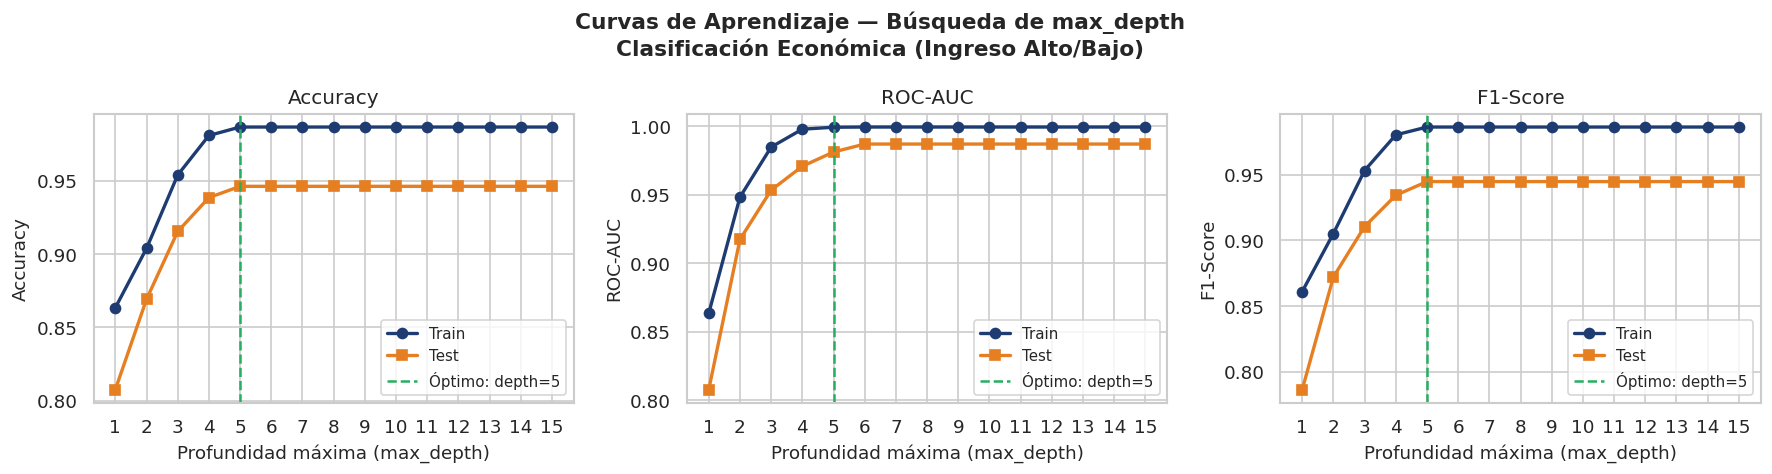

✅ Curvas de max_depth guardadas exitosamente en '../data/graficas/max_depth_arbol_economia.png'


In [38]:
# ── CELDA 7: Búsqueda de max_depth óptimo (Clasificación) ───────────────────────
import os

# Aseguramos que la carpeta para guardar las gráficas exista
os.makedirs('../data/graficas', exist_ok=True)

# Hacemos el split usando nuestra variable económica
X_tr, X_te, y_tr, y_te = train_test_split(X, y_clasificacion, test_size=0.20, random_state=42, stratify=y_clasificacion)

profundidades  = range(1, 16)
acc_train, acc_test   = [], []
auc_train, auc_test   = [], []
f1_train,  f1_test    = [], []

for d in profundidades:
    m = DecisionTreeClassifier(
        criterion='gini', max_depth=d,
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42
    )
    m.fit(X_tr, y_tr)

    # Métricas de Entrenamiento (Train)
    acc_train.append(accuracy_score(y_tr, m.predict(X_tr)))
    auc_train.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))
    f1_train.append(f1_score(y_tr, m.predict(X_tr), zero_division=0))
    
    # Métricas de Prueba (Test)
    acc_test.append(accuracy_score(y_te, m.predict(X_te)))
    auc_test.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
    f1_test.append(f1_score(y_te, m.predict(X_te), zero_division=0))

# Mejor max_depth según F1-Score en test (datos no vistos)
mejor_depth = list(profundidades)[int(np.argmax(f1_test))]
print(f"🏆 Mejor max_depth según F1-Score (test): {mejor_depth}")
print(f"   F1-Score test en depth={mejor_depth}: {max(f1_test):.4f}")

# ── Gráfico: Curvas de entrenamiento vs prueba ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Curvas de Aprendizaje — Búsqueda de max_depth\nClasificación Económica (Ingreso Alto/Bajo)', fontsize=13, fontweight='bold')

metricas_plot = [
    ('Accuracy',  acc_train, acc_test),
    ('ROC-AUC',   auc_train, auc_test),
    ('F1-Score',  f1_train,  f1_test),
]
for ax, (titulo, train_vals, test_vals) in zip(axes, metricas_plot):
    ax.plot(profundidades, train_vals, 'o-', color='#1e3c72', lw=2, label='Train')
    ax.plot(profundidades, test_vals,  's-', color='#e67e22', lw=2, label='Test')
    ax.axvline(x=mejor_depth, color='#27ae60', linestyle='--', lw=1.5, label=f'Óptimo: depth={mejor_depth}')
    ax.set_xlabel('Profundidad máxima (max_depth)', fontsize=11)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xticks(list(profundidades))

plt.tight_layout()
plt.savefig('../data/graficas/max_depth_arbol_economia.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curvas de max_depth guardadas exitosamente en '../data/graficas/max_depth_arbol_economia.png'")

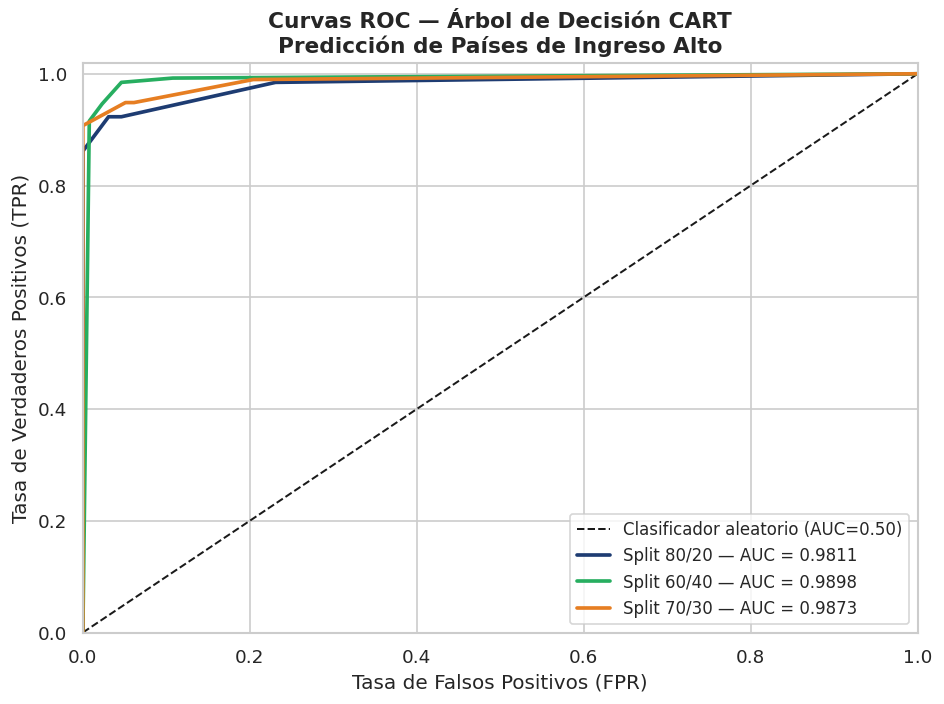

✅ Curvas ROC guardadas exitosamente en '../data/graficas/roc_arbol_economia.png'


In [39]:
# ── CELDA 8: Curvas ROC comparativas (Clasificación) ─────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
# Línea base: un modelo que adivina al azar (tirar una moneda)
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

# Dibujamos la curva de cada uno de nuestros splits (80/20, 60/40, 70/30)
for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Árbol de Decisión CART\nPredicción de Países de Ingreso Alto', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()

# Guardamos la imagen en la carpeta correspondiente
plt.savefig('../data/graficas/roc_arbol_economia.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Curvas ROC guardadas exitosamente en '../data/graficas/roc_arbol_economia.png'")

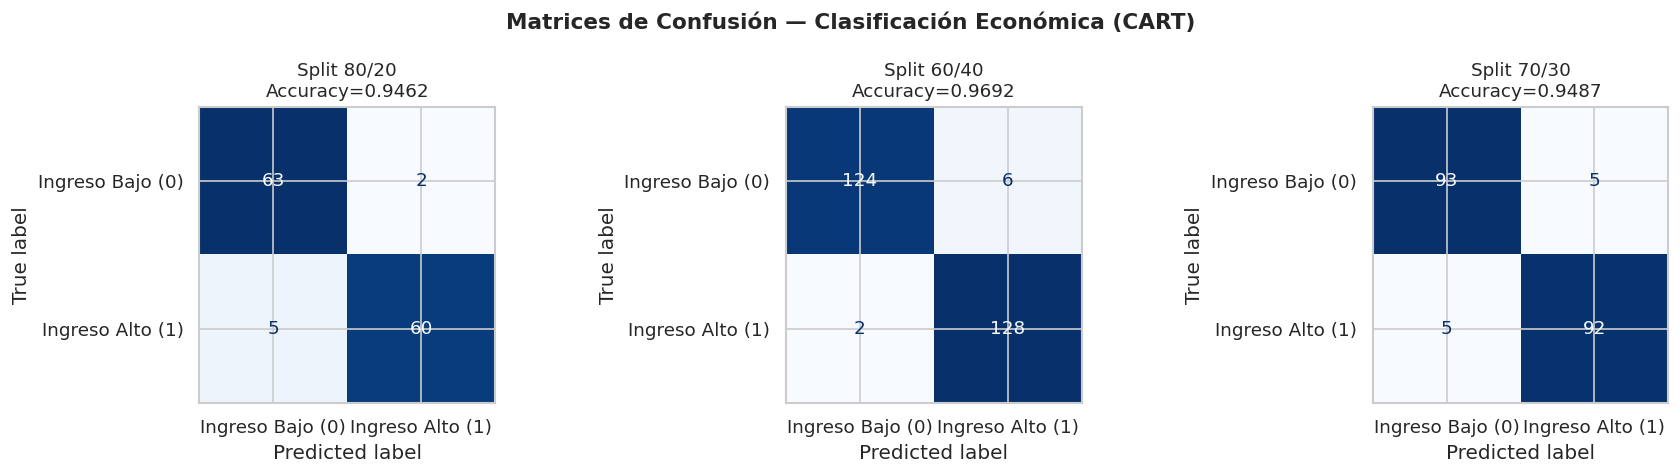

✅ Matrices de confusión guardadas exitosamente en '../data/graficas/confusion_arbol_economia.png'


In [40]:
# ── CELDA 9: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Clasificación Económica (CART)', fontsize=13, fontweight='bold')

for ax, r in zip(axes, resultados):
    cm   = confusion_matrix(r['y_test'], r['y_pred'])
    # Actualizamos las etiquetas para el contexto económico
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ingreso Bajo (0)', 'Ingreso Alto (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig('../data/graficas/confusion_arbol_economia.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Matrices de confusión guardadas exitosamente en '../data/graficas/confusion_arbol_economia.png'")

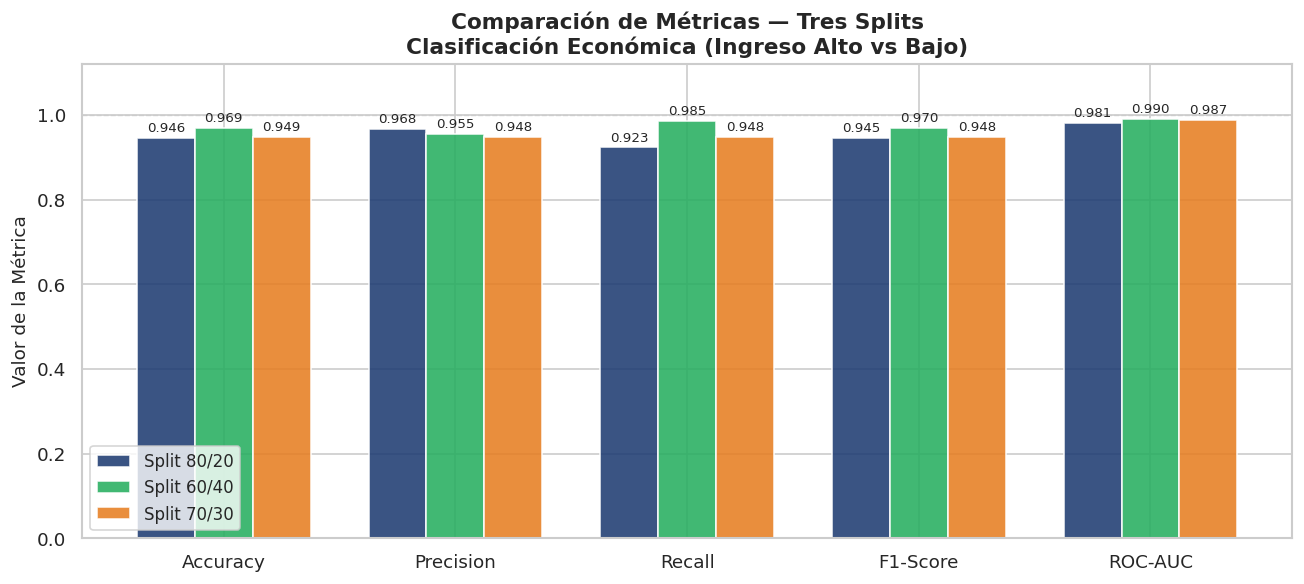

✅ Gráfico de métricas guardado exitosamente en '../data/graficas/metricas_comparativas_arbol_economia.png'


In [41]:
# ── CELDA 10: Gráfico comparativo de métricas ────────────────────────────────
# Aseguramos los colores por si se reinicia el kernel
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nClasificación Económica (Ingreso Alto vs Bajo)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()

# Guardamos la imagen con el nombre correspondiente al proyecto
plt.savefig('../data/graficas/metricas_comparativas_arbol_economia.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico de métricas guardado exitosamente en '../data/graficas/metricas_comparativas_arbol_economia.png'")

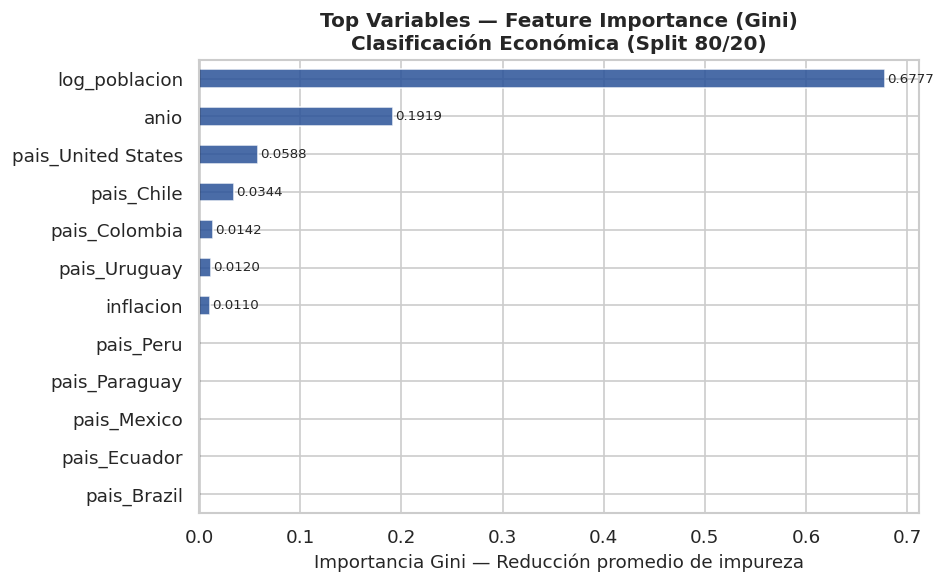

✅ Feature importance guardada exitosamente en '../data/graficas/feature_importance_arbol_economia.png'

📊 Suma de todas las importancias: 1.000000  (debe ser ≈ 1.0)

Top 5 variables más importantes para clasificar a los países:
log_poblacion         0.677703
anio                  0.191858
pais_United States    0.058837
pais_Chile            0.034385
pais_Colombia         0.014178


In [42]:
# ── CELDA 11: Importancia de variables (Feature Importance Gini) ─────────────
modelo_ref    = resultados[0]['modelo']   # Usamos el modelo del Split 80/20 como referencia
importancias  = pd.Series(modelo_ref.feature_importances_, index=X.columns)
# Tomamos las 12 variables que más peso tuvieron en la decisión
importancias_ord = importancias.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
importancias_ord.plot(kind='barh', ax=ax, color='#2a5298', alpha=0.85)
ax.set_xlabel('Importancia Gini — Reducción promedio de impureza', fontsize=11)
ax.set_title('Top Variables — Feature Importance (Gini)\nClasificación Económica (Split 80/20)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Anotar los valores exactos junto a las barras
for patch in ax.patches:
    width = patch.get_width()
    if width > 0.001:
        ax.text(width + 0.002, patch.get_y() + patch.get_height() / 2,
                f'{width:.4f}', va='center', fontsize=8)

plt.tight_layout()
# Guardamos la gráfica con el nombre del proyecto económico
plt.savefig('../data/graficas/feature_importance_arbol_economia.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Feature importance guardada exitosamente en '../data/graficas/feature_importance_arbol_economia.png'")
print(f"\n📊 Suma de todas las importancias: {importancias.sum():.6f}  (debe ser ≈ 1.0)")
print(f"\nTop 5 variables más importantes para clasificar a los países:")
print(importancias.sort_values(ascending=False).head(5).to_string())

In [43]:
# ── CELDA 12: DataFrame resumen de métricas ──────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS ECONÓMICAS':^65}")
print("=" * 65)

# Mostramos la tabla con un gradiente de color para identificar rápido los mejores valores
display(resumen.style
    .background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption("Árbol de Decisión CART — Clasificación Binaria: Ingreso Alto vs. Bajo")
)

print("\n📌 Comparación conceptual de modelos:")
print("   · Regresión Logística — traza una frontera lineal, requiere escalado, interpreta coeficientes.")
print("   · Árbol CART          — crea reglas de negocio (if/else), no requiere escalado, usa importancia Gini.")
print(f"\n   Mejor profundidad (max_depth) encontrada en la sección de validación: {mejor_depth}")

               TABLA FINAL DE MÉTRICAS ECONÓMICAS                


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,520,130,0.9462,0.9677,0.9231,0.9449,0.9811
Split 60/40,390,260,0.9692,0.9552,0.9846,0.9697,0.9898
Split 70/30,455,195,0.9487,0.9485,0.9485,0.9485,0.9873



📌 Comparación conceptual de modelos:
   · Regresión Logística — traza una frontera lineal, requiere escalado, interpreta coeficientes.
   · Árbol CART          — crea reglas de negocio (if/else), no requiere escalado, usa importancia Gini.

   Mejor profundidad (max_depth) encontrada en la sección de validación: 5
